In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_spellchecker_dataset.csv
/kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_vocabulary.txt


In [43]:
import kagglehub

# Download the Georgian Spellchecker dataset
dataset_path = kagglehub.dataset_download('giorgicheishvili/georgian-spellchecker-dataset')
print(f"Dataset downloaded to: {dataset_path}")

# List all files in the dataset
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Dataset downloaded to: /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset
/kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_spellchecker_dataset.csv
/kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_vocabulary.txt


In [44]:
import re
import random
import pickle

from collections import Counter

import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [45]:
# ── Locate dataset files from the downloaded Kaggle dataset ────────────────
CSV_PATH   = os.path.join(dataset_path, "georgian_spellchecker_dataset.csv")
VOCAB_PATH = os.path.join(dataset_path, "georgian_vocabulary.txt")

# Fallback: search subdirectories in case kagglehub nests files
if not os.path.exists(CSV_PATH):
    for dirname, _, filenames in os.walk(dataset_path):
        for filename in filenames:
            full = os.path.join(dirname, filename)
            if filename == "georgian_spellchecker_dataset.csv":
                CSV_PATH = full
            if filename == "georgian_vocabulary.txt":
                VOCAB_PATH = full

print(f"CSV path  : {CSV_PATH}")
print(f"Vocab path: {VOCAB_PATH}")
assert os.path.exists(CSV_PATH),   f"CSV not found at {CSV_PATH}"
assert os.path.exists(VOCAB_PATH), f"Vocab not found at {VOCAB_PATH}"
print("Both files located ✓")


CSV path  : /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_spellchecker_dataset.csv
Vocab path: /kaggle/input/datasets/giorgicheishvili/georgian-spellchecker-dataset/georgian_vocabulary.txt
Both files located ✓


In [46]:
# ── Load the dataset ───────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Total rows    : {len(df):,}")
print(f"Unique targets: {df['target_word'].nunique():,}")

already_correct = (df['input_word'] == df['target_word']).sum()
print(f"Clean pairs   : {already_correct:,}  ({100*already_correct/len(df):.1f}%)")
print(f"Corrupted     : {len(df)-already_correct:,}  ({100*(len(df)-already_correct)/len(df):.1f}%)")
df.head(10)


Total rows    : 332,132
Unique targets: 110,734
Clean pairs   : 110,734  (33.3%)
Corrupted     : 221,398  (66.7%)


,input_word,target_word
0,მეტრევეელს,მეტრეველს
1,ეთნიკურ,ეთნიკურ
2,რემი,ერმი
3,ჰარჯკი,ჰარუკი
4,დაუნდობლობოს,დაუნდობლობის
5,ჯაჭვი,ჯაჭვში
6,მოუუვიდათ,მოუვიდათ
7,თვითონვე,თვითონვე
8,დმნაისიც,დმანისიც
9,ნახხავ,ნახავ


In [47]:
# ── Show representative examples from the dataset ──────────────────────────
print("Sample corrupted pairs:")
corrupted_sample = df[df['input_word'] != df['target_word']].sample(15, random_state=SEED)
for _, row in corrupted_sample.iterrows():
    print(f"  {row['input_word']:<20} → {row['target_word']}")

print()
print("Sample clean pairs:")
clean_sample = df[df['input_word'] == df['target_word']].sample(5, random_state=SEED)
for _, row in clean_sample.iterrows():
    print(f"  {row['input_word']:<20} → {row['target_word']}  ✓")


Sample corrupted pairs:
  საქალლები            → საქალები
  შპოტსმეენი           → სპოტსმენი
  პრროფილი             → პროფილი
  უფოსზე               → უფროსზე
  მააონეზი             → მაონეზი
  ისაარლოვი            → ისარლოვი
  მხადგრძელს           → მხარგრძელს
  საი                  → სადი
  გაქავედა             → გაქვაედა
  სიზმრაი              → სიზმარი
  მოცრჩეეთ             → მოვრჩეთ
  სილიანოვსკაა         → სილიანოვსკა
  საპორტტო             → საპორტო
  კიღჩხიბიი            → კირჩხიბი
  დაგაბრუნოთ           → დავაბრუნოთ

Sample clean pairs:
  გამარჯვებულ          → გამარჯვებულ  ✓
  ტანგი                → ტანგი  ✓
  შახვეტილა            → შახვეტილა  ✓
  ანკლავი              → ანკლავი  ✓
  მეწამულ              → მეწამულ  ✓


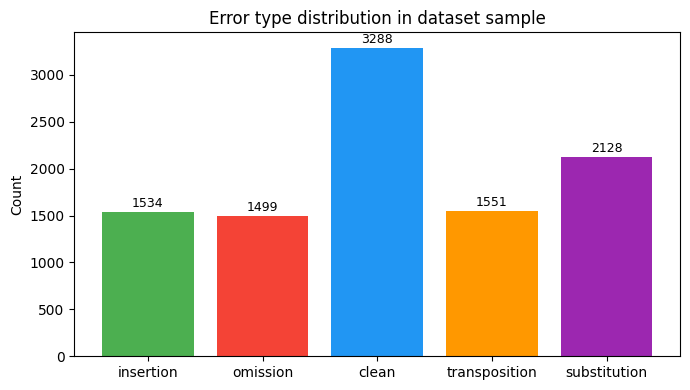

In [48]:
# ── Error-type distribution (inferred from edit distance) ──────────────────
def classify_error(inp, tgt):
    if inp == tgt:
        return 'clean'
    dl = len(inp) - len(tgt)
    if dl > 0:   return 'omission'
    if dl < 0:   return 'insertion'
    diffs = [(a, b) for a, b in zip(inp, tgt) if a != b]
    if len(diffs) == 2 and diffs[0][0] == diffs[1][1] and diffs[0][1] == diffs[1][0]:
        return 'transposition'
    return 'substitution'

sample = df.sample(min(10000, len(df)), random_state=SEED)
error_counts = Counter(classify_error(r['input_word'], r['target_word'])
                       for _, r in sample.iterrows())

labels = list(error_counts.keys())
sizes  = list(error_counts.values())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, sizes, color=['#4CAF50','#F44336','#2196F3','#FF9800','#9C27B0'])
ax.set_title("Error type distribution in dataset sample")
ax.set_ylabel("Count")
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [49]:
# ── Build character vocabulary from the dataset ────────────────────────────
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

all_chars = set()
for word in df['target_word']:
    all_chars.update(word)
for word in df['input_word']:
    all_chars.update(word)

vocab_chars    = sorted(all_chars)
special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

char2idx = {tok: i for i, tok in enumerate(special_tokens)}
for i, ch in enumerate(vocab_chars):
    char2idx[ch] = i + len(special_tokens)

idx2char = {v: k for k, v in char2idx.items()}

PAD_IDX  = char2idx[PAD_TOKEN]
SOS_IDX  = char2idx[SOS_TOKEN]
EOS_IDX  = char2idx[EOS_TOKEN]
UNK_IDX  = char2idx[UNK_TOKEN]
VOCAB_SIZE = len(char2idx)

print(f"Vocabulary size : {VOCAB_SIZE} tokens")
print(f"  Special tokens: {len(special_tokens)}")
print(f"  Unique chars  : {len(vocab_chars)}")
print(f"  Sample chars  : {vocab_chars[:10]}")


Vocabulary size : 42 tokens
  Special tokens: 4
  Unique chars  : 38
  Sample chars  : ['ა', 'ბ', 'გ', 'დ', 'ე', 'ვ', 'ზ', 'თ', 'ი', 'კ']


In [50]:
# ── Encoder / decoder helpers ──────────────────────────────────────────────
def encode_word(word):
    """Convert a word string to a list of integer indices."""
    return [char2idx.get(ch, UNK_IDX) for ch in word]

def decode_indices(indices):
    """Convert a list of integer indices back to a word string."""
    chars = []
    for idx in indices:
        if idx == EOS_IDX:
            break
        if idx in (PAD_IDX, SOS_IDX):
            continue
        chars.append(idx2char.get(idx, '?'))
    return ''.join(chars)

# Quick sanity check
test_word = 'გამარჯობა'
encoded   = encode_word(test_word)
decoded   = decode_indices(encoded)
print(f"Original : {test_word}")
print(f"Encoded  : {encoded}")
print(f"Decoded  : {decoded}")
assert test_word == decoded, "Round-trip encode/decode failed!"
print("Round-trip OK ✓")


Original : გამარჯობა
Encoded  : [6, 4, 15, 4, 20, 35, 17, 5, 4]
Decoded  : გამარჯობა
Round-trip OK ✓


In [51]:
class SpellcheckDataset(Dataset):
    """
    Each item: (encoder_input, decoder_input, decoder_target)
      encoder_input  : corrupted word indices
      decoder_input  : [SOS] + correct word indices  (teacher forcing input)
      decoder_target : correct word indices + [EOS]  (what we compare against)
    """
    def __init__(self, dataframe):
        self.pairs = []
        for _, row in dataframe.iterrows():
            src = encode_word(row['input_word'])
            tgt = encode_word(row['target_word'])
            self.pairs.append((
                torch.tensor(src,                  dtype=torch.long),
                torch.tensor([SOS_IDX] + tgt,      dtype=torch.long),
                torch.tensor(tgt + [EOS_IDX],      dtype=torch.long),
            ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


def collate_fn(batch):
    """
    Pads variable-length sequences within a batch to the same length.
    Returns: enc_in, dec_in, dec_tgt — all shape (batch, seq_len)
    """
    enc_ins, dec_ins, dec_tgts = zip(*batch)
    enc_ins  = pad_sequence(enc_ins,  batch_first=True, padding_value=PAD_IDX)
    dec_ins  = pad_sequence(dec_ins,  batch_first=True, padding_value=PAD_IDX)
    dec_tgts = pad_sequence(dec_tgts, batch_first=True, padding_value=PAD_IDX)
    return enc_ins, dec_ins, dec_tgts


# ── Train / validation split (90 / 10) ────────────────────────────────────
df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split_idx   = int(len(df_shuffled) * 0.9)
df_train    = df_shuffled.iloc[:split_idx]
df_val      = df_shuffled.iloc[split_idx:]

print(f"Train size : {len(df_train):,}")
print(f"Val size   : {len(df_val):,}")

BATCH_SIZE = 256

train_dataset = SpellcheckDataset(df_train)
val_dataset   = SpellcheckDataset(df_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")


Train size : 298,918
Val size   : 33,214
Train batches: 1168
Val batches  : 130


In [52]:
# ── Hyperparameters ────────────────────────────────────────────────────────
EMBED_DIM  = 64
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.3 # 0.4 maybe?


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))   # (batch, src_len, embed_dim)
        _, hidden = self.gru(embedded)                  # hidden: (num_layers, batch, hidden_dim)
        return hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden):
        # tgt_token: (batch,)  — one character at a time
        tgt_token = tgt_token.unsqueeze(1)                         # (batch, 1)
        embedded  = self.dropout(self.embedding(tgt_token))        # (batch, 1, embed_dim)
        output, hidden = self.gru(embedded, hidden)                # output: (batch, 1, hidden_dim)
        prediction = self.fc_out(output.squeeze(1))                # (batch, vocab_size)
        return prediction, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        src : (batch, src_len)
        tgt : (batch, tgt_len)  — decoder input starting with SOS

        teacher_forcing_ratio:
            Probability of feeding the ground-truth character as the next decoder
            input rather than the decoder's own prediction.
            0.5 gives a good balance: the model learns to recover from its own errors
            while still getting strong learning signal early in training.
        """
        batch_size = src.size(0)
        tgt_len    = tgt.size(1)

        outputs = torch.zeros(batch_size, tgt_len, VOCAB_SIZE).to(src.device)
        hidden  = self.encoder(src)
        dec_input = tgt[:, 0]  # first input is always <SOS>

        for t in range(tgt_len):
            output, hidden = self.decoder(dec_input, hidden)
            outputs[:, t, :] = output

            use_teacher = random.random() < teacher_forcing_ratio
            top1 = output.argmax(dim=1)
            dec_input = tgt[:, t] if use_teacher else top1

        return outputs


# ── Instantiate model ──────────────────────────────────────────────────────
encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)
model   = Seq2Seq(encoder, decoder).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)


Model parameters: 1,300,266
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(42, 64, padding_idx=0)
    (gru): GRU(64, 256, num_layers=2, batch_first=True, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(42, 64, padding_idx=0)
    (gru): GRU(64, 256, num_layers=2, batch_first=True, dropout=0.3)
    (fc_out): Linear(in_features=256, out_features=42, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


In [53]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2,
                                                 factor=0.5)

NUM_EPOCHS      = 40
PATIENCE        = 5
CHECKPOINT_PATH = "/kaggle/working/best_model.pt"


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for enc_in, dec_in, dec_tgt in loader:
            enc_in  = enc_in.to(DEVICE)
            dec_in  = dec_in.to(DEVICE)
            dec_tgt = dec_tgt.to(DEVICE)

            tf_ratio = 0.5 if train else 0.0
            output   = model(enc_in, dec_in, teacher_forcing_ratio=tf_ratio)

            B, T, V = output.shape
            loss = criterion(output.reshape(B * T, V), dec_tgt.reshape(B * T))

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

            predictions = output.reshape(B * T, V).argmax(dim=-1)
            targets = dec_tgt.reshape(B * T)
            non_pad_mask = targets != PAD_IDX
            total_correct += ((predictions == targets) & non_pad_mask).sum().item()
            total_tokens += non_pad_mask.sum().item()

    return total_loss / len(loader), (total_correct / total_tokens if total_tokens > 0 else 0.0)


train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss     = float('inf')
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc   = run_epoch(val_loader,   train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'char2idx'   : char2idx,
            'idx2char'   : idx2char,
            'hyperparams': {
                'embed_dim' : EMBED_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'dropout'   : DROPOUT,
                'vocab_size': VOCAB_SIZE,
            }
        }, CHECKPOINT_PATH)
    else:
        epochs_no_improve += 1

    marker = " ← best" if improved else ""
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%{marker}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered — no improvement for {PATIENCE} epochs.")
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
print(f"Best checkpoint saved to: {CHECKPOINT_PATH}")

Epoch 01/40 | Train Loss: 1.3756 | Train Acc: 57.02% | Val Loss: 0.8302 | Val Acc: 74.50% ← best
Epoch 02/40 | Train Loss: 0.7461 | Train Acc: 77.45% | Val Loss: 0.6922 | Val Acc: 79.53% ← best
Epoch 03/40 | Train Loss: 0.6446 | Train Acc: 81.21% | Val Loss: 0.6616 | Val Acc: 80.75% ← best
Epoch 04/40 | Train Loss: 0.5980 | Train Acc: 82.78% | Val Loss: 0.6214 | Val Acc: 82.18% ← best
Epoch 05/40 | Train Loss: 0.5682 | Train Acc: 83.70% | Val Loss: 0.6248 | Val Acc: 82.03%
Epoch 06/40 | Train Loss: 0.5464 | Train Acc: 84.34% | Val Loss: 0.5940 | Val Acc: 83.05% ← best
Epoch 07/40 | Train Loss: 0.5310 | Train Acc: 84.83% | Val Loss: 0.5872 | Val Acc: 83.12% ← best
Epoch 08/40 | Train Loss: 0.5170 | Train Acc: 85.23% | Val Loss: 0.5823 | Val Acc: 83.39% ← best
Epoch 09/40 | Train Loss: 0.5039 | Train Acc: 85.62% | Val Loss: 0.5759 | Val Acc: 83.75% ← best
Epoch 10/40 | Train Loss: 0.4949 | Train Acc: 85.89% | Val Loss: 0.6016 | Val Acc: 82.84%
Epoch 11/40 | Train Loss: 0.4870 | Train Acc

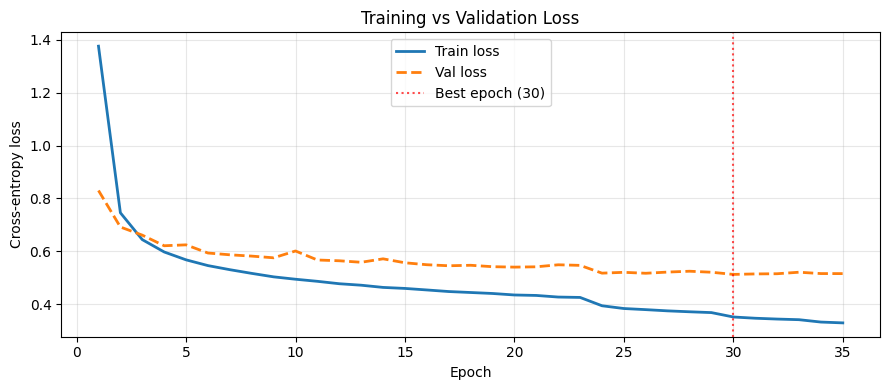

Loss curve saved to /kaggle/working/loss_curves.png


In [54]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label='Train loss', linewidth=2)
ax.plot(epochs_range, val_losses,   label='Val loss',   linewidth=2, linestyle='--')

best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(best_epoch, color='red', linestyle=':', alpha=0.7,
           label=f'Best epoch ({best_epoch})')

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves.png", dpi=150)
plt.show()
print("Loss curve saved to /kaggle/working/loss_curves.png")


In [55]:
# ── Load best checkpoint ───────────────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']}")


def correct_word_internal(word, max_len=50):
    """
    Greedy decoding: run the encoder once, then step the decoder
    one character at a time until EOS or max_len is reached.
    """
    model.eval()
    with torch.no_grad():
        src     = torch.tensor(encode_word(word), dtype=torch.long).unsqueeze(0).to(DEVICE)
        hidden  = model.encoder(src)
        dec_input = torch.tensor([SOS_IDX], dtype=torch.long).to(DEVICE)
        result  = []

        for _ in range(max_len):
            output, hidden = model.decoder(dec_input, hidden)
            top1 = output.argmax(dim=1)
            if top1.item() == EOS_IDX:
                break
            result.append(top1.item())
            dec_input = top1

    return decode_indices(result)


# ── Sample predictions on validation set ──────────────────────────────────
sample_val = df_val[df_val['input_word'] != df_val['target_word']].sample(20, random_state=SEED)
print(f"{'Input':<25} {'Expected':<25} {'Predicted':<25} {'OK?'}")
print("-" * 85)
correct_count = 0
for _, row in sample_val.iterrows():
    pred = correct_word_internal(row['input_word'])
    ok   = "✓" if pred == row['target_word'] else "✗"
    if pred == row['target_word']:
        correct_count += 1
    print(f"{row['input_word']:<25} {row['target_word']:<25} {pred:<25} {ok}")

print(f"\nAccuracy on sample: {correct_count}/20 ({correct_count*5}%)")


Loaded best model from epoch 30
Input                     Expected                  Predicted                 OK?
-------------------------------------------------------------------------------------
ხაენინე                   ხეანინე                   შაეეენ                    ✗
დუეელმადე                 დუელამდე                  დუეეადდე                  ✗
პოომარი                   პომარი                    ფოამმრი                   ✗
ამჰოყვებოდაო              ამოჰყვებოდაო              ამოჰოვებოდაო              ✗
იგრძნოგა                  იგრძნობა                  ვგრძონბა                  ✗
ბაპტიმორი                 ბალტიმორი                 ბალტიიორიი                ✗
საცჰენიისს                საცხენისის                საცხენისს                 ✗
ჭან                       ჭანი                      ჷაენნნ                    ✗
იკნოჟურნალი               კინოჟურნალი               იინოჟურნილი               ✗
რონის                     რომის                     რონის                     ✗


In [56]:
# ── Word-level accuracy on the full validation set ─────────────────────────
total, correct = 0, 0
for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Evaluating"):
    pred = correct_word_internal(row['input_word'])
    if pred == row['target_word']:
        correct += 1
    total += 1

print(f"\nFull validation word accuracy: {correct}/{total} = {100*correct/total:.2f}%")


Evaluating: 100%|██████████| 33214/33214 [02:45<00:00, 201.14it/s]


Full validation word accuracy: 8408/33214 = 25.31%


In [57]:
# Kaggle persists everything written to /kaggle/working/ as output when you
# click "Save & Run All". Both files below will appear in the notebook's output
# and can be downloaded or attached to inference.ipynb as a dataset.

import pickle

with open("/kaggle/working/vocab.pkl", "wb") as f:
    pickle.dump({'char2idx': char2idx, 'idx2char': idx2char}, f)

print("Saved to /kaggle/working/:")
print("  best_model.pt  — full checkpoint (weights + vocab + hyperparams)")
print("  vocab.pkl      — vocabulary mappings only")
print("  loss_curves.png — training curve plot")
print()
print("These files are all that inference.ipynb needs — no training code required there.")


Saved to /kaggle/working/:
  best_model.pt  — full checkpoint (weights + vocab + hyperparams)
  vocab.pkl      — vocabulary mappings only
  loss_curves.png — training curve plot

These files are all that inference.ipynb needs — no training code required there.
